# Task 4B: SEAL-Augmented LoRA Fine-Tuning

Image + Prompt → Description + JSON

GPT-4.1 generates justified descriptions (chain-of-thought distillation).
The frontier model sees the image AND knows the correct answer — it explains WHY.
18 images × (3 descriptions + 1 direct) = 72 training examples.

## Setup

In [1]:
import os, json, re, time, torch, gc, random, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')


GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Step 1: Select Training Images

In [ ]:
random.seed(SEED)
IMAGES_PER_CLASS = 2

with open(TRAIN_MANIFEST) as f:
    train_manifest = json.load(f)
by_class = defaultdict(list)
for e in train_manifest: by_class[e['class']].append(e)
selected = []
for cls in sorted(by_class):
    random.shuffle(by_class[cls])
    selected.extend(by_class[cls][:IMAGES_PER_CLASS])
print(f'{len(selected)} training images selected')
for e in selected: print(f'  {e["class"]}: {e["image"]}')
os.environ['AZURE_OPENAI_API_KEY'] = <api-key>

18 training images selected
  A16: S2_A16_2.11.9.JPG
  A16: S2_A16_2.11.12.JPG
  A32: S1_A32_IMG_5567.JPG
  A32: S2_A32_3.11.22.JPG
  A8: S1_A8_IMG_5620.JPG
  A8: S1_A8_IMG_7735.JPG
  B16: S1_B16_IMG_7763.JPG
  B16: S2_B16_2.5.26.JPG
  B32: S2_B32_3.4.35.JPG
  B32: S1_B32_IMG_5908.JPG
  B8: S1_B8_IMG_5791.JPG
  B8: S1_B8_IMG_5633.JPG
  C16: S1_C16_IMG_7678.JPG
  C16: S2_C16_2.1.38.JPG
  C32: S2_C32_3.1.42.JPG
  C32: S1_C32_IMG_5870.JPG
  C8: S2_C8_1.1.9.JPG
  C8: S2_C8_1.1.6.JPG


## Step 2: Compute Training Prompt

In [3]:
sample_img = Image.open(os.path.join(TRAIN_DIR, selected[0]['image']))
train_scale = min(MAX_DIM / max(sample_img.size), 1.0)
train_gsd = ORIGINAL_GSD * train_scale
sample_img.close()
PROMPT = make_prompt(train_gsd)
print(f'Training GSD: {train_gsd:.1f} px/mm')
print(f'\nPrompt (same for training and eval):\n{PROMPT}')


Training GSD: 2.1 px/mm

Prompt (same for training and eval):
Classify this concrete aggregate photograph.
Ground sampling distance (GSD) = 2.1 px/mm.
At this GSD: 8mm stone ≈ 17px, 16mm ≈ 34px, 32mm ≈ 68px.

Classification axes:
1. MAX PARTICLE SIZE: estimate the largest stone's width in pixels, divide by GSD, round to 8, 16, or 32 mm.
2. GRADING (DIN 1045 standard — describes size DISTRIBUTION, not absolute size):
   - COARSE (A): particles concentrated near max size. Gaps between stones are EMPTY. Uniform, single-layer texture.
   - MEDIUM (B): balanced mix. Gaps PARTIALLY filled by smaller particles.
   - FINE (C): wide size range. Gaps COMPLETELY filled with small particles. Dense, packed texture.

Respond with JSON: {"max_particle_size_mm": <8, 16, or 32>, "grading": "<coarse, medium, or fine>"}


## Step 3: Generate Justified Descriptions via GPT-4.1

For each image, GPT-4.1 receives:
1. The actual image
2. The correct classification
3. DIN 1045 grading definitions

It generates a description explaining WHY the classification is correct.
We append the correct JSON ourselves.

In [4]:
from openai import AzureOpenAI

gpt_client = AzureOpenAI(
    azure_endpoint=AZURE_ENDPOINT,
    api_key=os.environ.get('AZURE_OPENAI_API_KEY', ''),
    api_version=AZURE_API_VERSION,
)

DESCRIBE_PROMPT = '''Look at this concrete aggregate image. The correct classification is:
- max_particle_size_mm: {size}
- grading: {grading}

DIN 1045 grading definitions:
- COARSE (A): particles concentrated near max size. Gaps between stones are EMPTY. Uniform texture.
- MEDIUM (B): balanced mix. Gaps PARTIALLY filled by smaller particles.
- FINE (C): wide size range. Gaps COMPLETELY filled with small particles. Dense, packed.

Explain WHY this classification is correct based on what you see:
1. Estimate the largest stone size
2. Describe the gaps between the largest stones — empty, partially filled, or completely filled?
3. Describe the overall texture — uniform or packed with mixed sizes?

Write 2-3 sentences justifying the classification. Be specific about what you see in THIS image.
Reply with ONLY the justification text. No JSON, no labels, just the explanation.'''

def encode_image(path):
    with open(path, 'rb') as f: return base64.b64encode(f.read()).decode('utf-8')

print(f'GPT-4.1 ready: {AZURE_ENDPOINT}')


GPT-4.1 ready: https://ether-openai.openai.azure.com/


In [5]:
# Remove "Respond with JSON" line for description examples
PROMPT_NO_JSON = '\n'.join(PROMPT.split('\n')[:-1])

if os.path.exists('training_data_augmented.jsonl'):
    with open('training_data_augmented.jsonl') as f:
        augmented_data = [json.loads(line) for line in f]
    print(f'Loaded existing: {len(augmented_data)} examples (delete file to regenerate)')
else:
    augmented_data = []
    for entry in selected:
        img_path = os.path.join(TRAIN_DIR, entry['image'])
        if not os.path.exists(img_path): continue
        cls = entry['class']
        gt_size, gt_grading = GT[cls]
        gt_json = json.dumps({'max_particle_size_mm': gt_size, 'grading': gt_grading})
        img_b64 = encode_image(img_path)
        
        print(f'  {cls}: {entry["image"]}', end='', flush=True)
        
        # Generate 3 justified descriptions — prompt WITHOUT "Respond with JSON" line
        for attempt in range(3):
            try:
                resp = gpt_client.chat.completions.create(
                    model=AZURE_DEPLOYMENT, max_tokens=512, temperature=0.7,
                    messages=[{'role':'user','content':[
                        {'type':'image_url','image_url':{'url':f'data:image/jpeg;base64,{img_b64}'}},
                        {'type':'text','text':DESCRIBE_PROMPT.format(size=gt_size, grading=gt_grading)}]}])
                description = resp.choices[0].message.content.strip()
                response = description + '\n' + gt_json
                augmented_data.append({'messages':[
                    {'role':'user','content':[{'type':'image','image':img_path},{'type':'text','text':PROMPT_NO_JSON}]},
                    {'role':'assistant','content': response}]})
                print('.', end='', flush=True)
            except Exception as e:
                print('X', end='', flush=True)
            time.sleep(0.3)
        
        # Also add 1 direct JSON-only pair — full prompt WITH "Respond with JSON"
        augmented_data.append({'messages':[
            {'role':'user','content':[{'type':'image','image':img_path},{'type':'text','text':PROMPT}]},
            {'role':'assistant','content': gt_json}]})
        print(' done')
    
    with open('training_data_augmented.jsonl', 'w') as f:
        for r in augmented_data: f.write(json.dumps(r) + '\n')
    print(f'\nSaved {len(augmented_data)} examples')


Loaded existing: 72 examples (delete file to regenerate)


In [6]:
if augmented_data:
    print('--- Sample justified response ---')
    print(augmented_data[0]['messages'][1]['content'])
    print(f'\n--- Sample direct response ---')
    # Find a direct-only one
    for d in augmented_data:
        if d['messages'][1]['content'].startswith('{'):
            print(d['messages'][1]['content']); break
print(augmented_data[0])

--- Sample justified response ---
The largest stones in this image appear to be around 16 mm, fitting the max_particle_size_mm: 16 classification. The gaps between the largest stones are mostly empty, with very few smaller particles filling the spaces, which is characteristic of a coarse grading. The overall texture looks uniform and not densely packed with mixed sizes, supporting the classification of coarse aggregate according to DIN 1045.
{"max_particle_size_mm": 16, "grading": "coarse"}

--- Sample direct response ---
{"max_particle_size_mm": 16, "grading": "coarse"}
{'messages': [{'role': 'user', 'content': [{'type': 'image', 'image': '../../datasets/granulometry/train/S2_A16_2.11.9.JPG'}, {'type': 'text', 'text': "Classify this concrete aggregate photograph.\nGround sampling distance (GSD) = 2.1 px/mm.\nAt this GSD: 8mm stone ≈ 17px, 16mm ≈ 34px, 32mm ≈ 68px.\n\nClassification axes:\n1. MAX PARTICLE SIZE: estimate the largest stone's width in pixels, divide by GSD, round to 8, 16

## Step 4: Load Model + Train

In [7]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import Dataset

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28)
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map='auto', torch_dtype=torch.bfloat16)
base_model.enable_input_require_grads()

lora_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS, task_type='CAUSAL_LM', bias='none')
print('Model loaded.')


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-14 09:48:26.706610: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 09:48:26.706663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 09:48:26.708447: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 09:48:26.716615: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary

Model loaded.


In [8]:
class GranulometryDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        with open(jsonl_path) as f:
            self.data = [json.loads(line) for line in f]
        self.processor = processor
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        entry = self.data[idx]
        msgs = entry['messages']
        img_path = next((c['image'] for c in msgs[0]['content'] if c['type']=='image'), None)
        user_text = next((c['text'] for c in msgs[0]['content'] if c['type']=='text'), '')
        assistant_text = msgs[1]['content']
        if not isinstance(assistant_text, str): assistant_text = json.dumps(assistant_text)
        image = Image.open(img_path).convert('RGB') if img_path else None
        chat = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':user_text}]},
                {'role':'assistant','content':[{'type':'text','text':assistant_text}]}]
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(text=[text], images=[image], return_tensors='pt', padding=True)
        input_ids = inputs['input_ids'].squeeze(0)
        labels = input_ids.clone()
        ast_tokens = self.processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        if len(ast_tokens) < len(labels): labels[:-len(ast_tokens)] = -100
        if image: image.close()
        return {'input_ids': input_ids, 'attention_mask': inputs['attention_mask'].squeeze(0),
                'labels': labels, 'pixel_values': inputs.get('pixel_values', None),
                'image_grid_thw': inputs.get('image_grid_thw', None)}

EPOCHS = 10
LR = 2e-5
GRAD_ACCUM = 4

def train_lora(base_model, data_path, output_dir, epochs=EPOCHS, lr=LR):
    model = get_peft_model(base_model, lora_config)
    model.gradient_checkpointing_enable()
    model.print_trainable_parameters()
    dataset = GranulometryDataset(data_path, processor)
    print(f'Training: {len(dataset)} examples, {epochs} epochs, lr={lr}')
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = max(len(dataset) * epochs // GRAD_ACCUM, 1)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(len(dataset)):
            batch = dataset[i]
            ids = batch['input_ids'].unsqueeze(0).to(model.device)
            mask = batch['attention_mask'].unsqueeze(0).to(model.device)
            lab = batch['labels'].unsqueeze(0).to(model.device)
            kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
            if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
            if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
            out = model(**kw)
            loss = out.loss / GRAD_ACCUM
            loss.backward()
            epoch_loss += loss.item() * GRAD_ACCUM
            if (i+1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
            del ids, mask, lab, out, loss; torch.cuda.empty_cache()
        avg = epoch_loss / len(dataset)
        losses.append(avg)
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e}')
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print(f'Adapter saved to {output_dir}/')
    model.unload()
    del model, optimizer, scheduler, dataset
    gc.collect(); torch.cuda.empty_cache()
    return losses

print('Ready.')


Ready.


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 72 examples, 10 epochs, lr=2e-05


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


  Epoch 1/10 — loss: 1.3712 — lr: 2.00e-05
  Epoch 5/10 — loss: 0.4422 — lr: 1.17e-05
  Epoch 10/10 — loss: 0.3514 — lr: 0.00e+00
Adapter saved to lora_augmented/


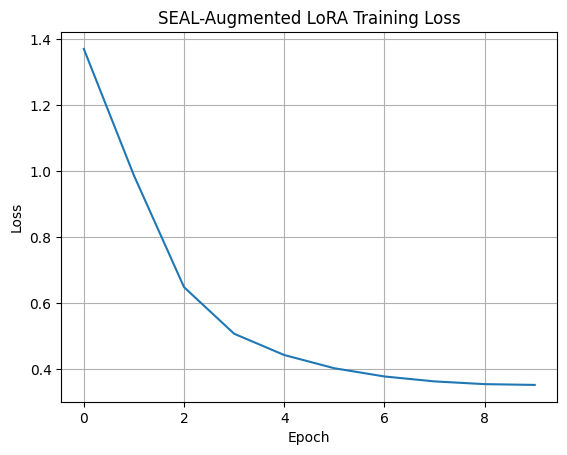

In [11]:
losses = train_lora(base_model, 'training_data_augmented.jsonl', 'lora_augmented')
plt.plot(losses); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('SEAL-Augmented LoRA Training Loss'); plt.grid(True); plt.show()


In [15]:
from peft import PeftModel

# Load the adapter from epoch 10
model = PeftModel.from_pretrained(base_model, 'lora_augmented')

# Unfreeze LoRA parameters for continued training
for name, param in model.named_parameters():
    if 'lora' in name.lower():
        param.requires_grad = True

model.gradient_checkpointing_enable()
model.train()
model.print_trainable_parameters()

dataset = GranulometryDataset('training_data_augmented.jsonl', processor)
REMAINING_EPOCHS = 20  # epochs 11-15
LR = 2e-5
GRAD_ACCUM = 4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = max(len(dataset) * REMAINING_EPOCHS // GRAD_ACCUM, 1)
scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)

losses = []
for epoch in range(REMAINING_EPOCHS):
    epoch_loss = 0
    for i in range(len(dataset)):
        batch = dataset[i]
        ids = batch['input_ids'].unsqueeze(0).to(model.device)
        mask = batch['attention_mask'].unsqueeze(0).to(model.device)
        lab = batch['labels'].unsqueeze(0).to(model.device)
        kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
        if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
        if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
        out = model(**kw)
        loss = out.loss / GRAD_ACCUM
        loss.backward()
        epoch_loss += loss.item() * GRAD_ACCUM
        if (i+1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
        del ids, mask, lab, out, loss; torch.cuda.empty_cache()
    avg = epoch_loss / len(dataset)
    losses.append(avg)
    print(f'  Epoch {epoch+21}/{20 + REMAINING_EPOCHS} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e}')

model.save_pretrained('lora_augmented')
print('Adapter updated.')
model.unload(); del model, optimizer, scheduler, dataset
gc.collect(); torch.cuda.empty_cache()


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
  Epoch 21/40 — loss: 0.2174 — lr: 1.00e-05
  Epoch 22/40 — loss: 0.2117 — lr: 2.00e-05
  Epoch 23/40 — loss: 0.2003 — lr: 1.98e-05
  Epoch 24/40 — loss: 0.1795 — lr: 1.94e-05
  Epoch 25/40 — loss: 0.1588 — lr: 1.87e-05
  Epoch 26/40 — loss: 0.1436 — lr: 1.77e-05
  Epoch 27/40 — loss: 0.1327 — lr: 1.64e-05
  Epoch 28/40 — loss: 0.1301 — lr: 1.50e-05
  Epoch 29/40 — loss: 0.1251 — lr: 1.34e-05
  Epoch 30/40 — loss: 0.1156 — lr: 1.17e-05
  Epoch 31/40 — loss: 0.1052 — lr: 1.00e-05
  Epoch 32/40 — loss: 0.0968 — lr: 8.26e-06
  Epoch 33/40 — loss: 0.0867 — lr: 6.58e-06
  Epoch 34/40 — loss: 0.0777 — lr: 5.00e-06
  Epoch 35/40 — loss: 0.0636 — lr: 3.57e-06
  Epoch 36/40 — loss: 0.0579 — lr: 2.34e-06
  Epoch 37/40 — loss: 0.0531 — lr: 1.34e-06
  Epoch 38/40 — loss: 0.0507 — lr: 6.03e-07
  Epoch 39/40 — loss: 0.0490 — lr: 1.52e-07
  Epoch 40/40 — loss: 0.0485 — lr: 0.00e+00
Adapter updated.


## Step 5: Evaluate

In [16]:
def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    sm = re.search(r'"max_particle_size_mm"\s*:\s*(\d+)', raw)
    gm = re.search(r'"grading"\s*:\s*"(\w+)"', raw)
    if sm and gm: return {'max_particle_size_mm': int(sm.group(1)), 'grading': gm.group(1)}
    return None

def run_eval(model, processor, manifest, max_dim=MAX_DIM):
    model.eval()
    results=[]; cs=0; cg=0; vj=0; tt=0
    for i, entry in enumerate(manifest):
        img_path = os.path.join(TEST_DIR, entry['image'])
        if not os.path.exists(img_path): continue
        image = Image.open(img_path).convert('RGB')
        scale = min(max_dim/max(image.size), 1.0)
        gsd = ORIGINAL_GSD * scale
        prompt = make_prompt(gsd)
        msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':prompt}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
        t=time.time()
        with torch.no_grad(): ids = model.generate(**inputs, max_new_tokens=256, temperature=0.1, do_sample=True)
        elapsed=time.time()-t; tt+=elapsed
        out = processor.batch_decode(ids[:,inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
        del inputs, ids; image.close(); torch.cuda.empty_cache()
        parsed = parse_response(out)
        gs=entry['max_particle_size_mm']; gg=entry['grading']; so=False; go=False
        if parsed:
            vj+=1; ps=parsed.get('max_particle_size_mm')
            if isinstance(ps,str): ps=int(ps) if ps.isdigit() else None
            if ps==gs: so=True; cs+=1
            if parsed.get('grading','').lower()==gg: go=True; cg+=1
        results.append({'image':entry['image'],'class':entry['class'],'gt_size':gs,'gt_grading':gg,
            'predicted':parsed,'raw':out,'size_correct':so,'grading_correct':go,'valid_json':parsed is not None,'time_s':round(elapsed,2)})
        if (i+1)%20==0:
            n=i+1; print(f'  [{n}/{len(manifest)}] Size:{cs}/{n}({cs/n*100:.0f}%) Grade:{cg}/{n}({cg/n*100:.0f}%)')
    return results, cs, cg, vj, tt

with open(TEST_MANIFEST) as f: test_manifest = json.load(f)
print(f'Test set: {len(test_manifest)} images')


Test set: 108 images


### Quick Eval (9 images)

In [17]:
quick = [next(e for e in test_manifest if e['class']==cls) for cls in sorted(GT.keys())]
model = PeftModel.from_pretrained(base_model, 'lora_augmented')
r, cs, cg, vj, tt = run_eval(model, processor, quick)
print(f'\nSize: {cs}/{len(r)} ({cs/len(r)*100:.0f}%) | Grading: {cg}/{len(r)} ({cg/len(r)*100:.0f}%)')
for x in r:
    p=x['predicted']; ps=p.get('max_particle_size_mm','?') if p else '?'; pg=p.get('grading','?') if p else '?'
    sv='✓' if x['size_correct'] else '✗'; gv='✓' if x['grading_correct'] else '✗'
    print(f'  {x["class"]:>3} GT:{x["gt_size"]}mm/{x["gt_grading"]} Pred:{ps}mm/{pg} {sv}{gv}')
    if x['raw'] and len(x['raw']) > 60: print(f'      Raw: {x["raw"][:100]}...')
model.unload(); del model; gc.collect(); torch.cuda.empty_cache()



Size: 9/9 (100%) | Grading: 8/9 (89%)
  A16 GT:16mm/coarse Pred:16mm/coarse ✓✓
  A32 GT:32mm/coarse Pred:32mm/coarse ✓✓
   A8 GT:8mm/coarse Pred:8mm/medium ✓✗
  B16 GT:16mm/medium Pred:16mm/medium ✓✓
  B32 GT:32mm/medium Pred:32mm/medium ✓✓
   B8 GT:8mm/medium Pred:8mm/medium ✓✓
  C16 GT:16mm/fine Pred:16mm/fine ✓✓
  C32 GT:32mm/fine Pred:32mm/fine ✓✓
   C8 GT:8mm/fine Pred:8mm/fine ✓✓


### Full Eval (108 images)

In [18]:
model = PeftModel.from_pretrained(base_model, 'lora_augmented')
r_full, cs, cg, vj, tt = run_eval(model, processor, test_manifest)
n=len(r_full); both=sum(1 for x in r_full if x['size_correct'] and x['grading_correct'])
print(f'\nJSON: {vj}/{n} ({vj/n*100:.0f}%) | Size: {cs}/{n} ({cs/n*100:.1f}%) | Grading: {cg}/{n} ({cg/n*100:.1f}%) | Both: {both}/{n} ({both/n*100:.1f}%)')
model.unload(); del model; gc.collect(); torch.cuda.empty_cache()

with open('results_augmented.json','w') as f:
    json.dump({'model':MODEL_ID,'adapter':'lora_augmented','phase':'fine_tuned','total_images':n,
        'json_validity_pct':round(vj/n*100,1),'size_accuracy_pct':round(cs/n*100,1),
        'grading_accuracy_pct':round(cg/n*100,1),'both_correct_pct':round(both/n*100,1),
        'avg_inference_time_s':round(tt/n,2),'results':r_full}, f, indent=2)
print('Saved results_augmented.json')


  [20/108] Size:20/20(100%) Grade:16/20(80%)
  [40/108] Size:38/40(95%) Grade:35/40(88%)
  [60/108] Size:55/60(92%) Grade:51/60(85%)
  [80/108] Size:74/80(92%) Grade:70/80(88%)
  [100/108] Size:92/100(92%) Grade:85/100(85%)

JSON: 108/108 (100%) | Size: 99/108 (91.7%) | Grading: 93/108 (86.1%) | Both: 86/108 (79.6%)
Saved results_augmented.json
